In [ ]:
#Librerías

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
import statsmodels.api as sm

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from ipywidgets import interact, FloatSlider
from IPython.display import display
from plotly.subplots import make_subplots
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.stattools import adfuller, kpss

In [ ]:
df = pd.read_csv('/content/dataset_ventas_pyme_2013_2024.csv')
df["Fecha"] = pd.to_datetime(df["Fecha"])
df.set_index('Fecha', inplace=True)
df.sort_index(inplace=True)
df.head(100)

,Total_Ventas,Categoria
Fecha,,
2013-01-01,8529,Decoración
2013-02-01,8327,Dormitorio
2013-03-01,9244,Cocina
2013-04-01,9244,Baño
2013-05-01,9172,Dormitorio
...,...,...
2020-12-01,12196,Decoración
2021-01-01,12498,Decoración
2021-02-01,12387,Cocina


In [ ]:
# prompt: Del df, quiero saber los distintos valores de la columna Categoría

df['Categoria'].unique()

array(['Decoración', 'Dormitorio', 'Cocina', 'Baño'], dtype=object)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 2013-01-01 to 2024-12-01
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Total_Ventas  144 non-null    int64 
 1   Categoria     144 non-null    object
dtypes: int64(1), object(1)
memory usage: 3.4+ KB


In [ ]:
df.describe().round(2)

,Total_Ventas
count,144.00
mean,10891.22
std,1986.88
min,6896.00
25%,9253.75
50%,10732.00
75%,12510.75
max,14894.00


In [ ]:
freq = pd.infer_freq(df.index)
print(freq)

MS


In [ ]:
#Gráfico de línea

fig = go.Figure()

fig.add_trace(go.Scatter(x=df.index, y=df['Total_Ventas'],
                         mode='lines',
                         name='Ventas',
                         line=dict(color='green', width=2)))

fig.update_layout(
    title={
        'text': 'Ventas totales a lo largo del Tiempo',
        'y':0.9,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top'
    },
    xaxis_title='Fecha',
    yaxis_title='Ventas',
    hovermode='x unified',
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    ),
    template= 'seaborn'
)

fig.show()

In [ ]:
df.describe().round(2)

,Total_Ventas
count,144.00
mean,10891.22
std,1986.88
min,6896.00
25%,9253.75
50%,10732.00
75%,12510.75
max,14894.00


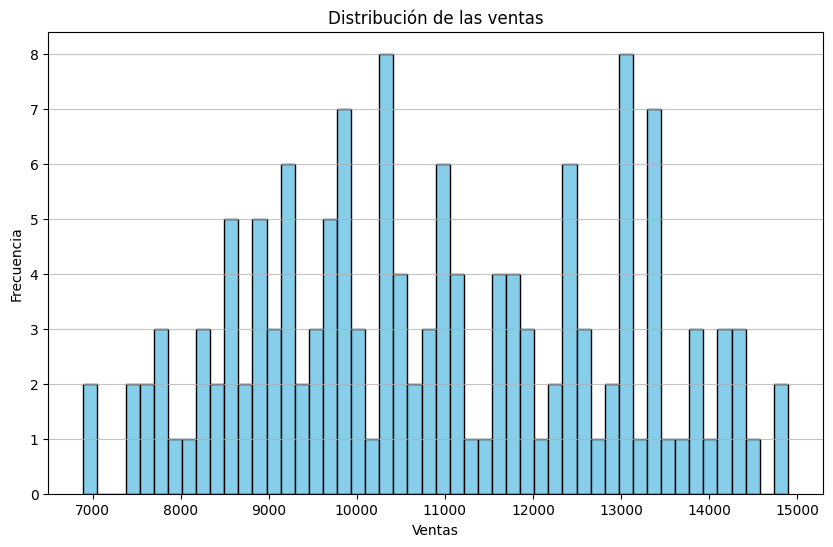

In [ ]:
# Histograma

plt.figure(figsize=(10, 6))
plt.hist(df['Total_Ventas'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribución de las ventas')
plt.xlabel('Ventas')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.75)
plt.show()

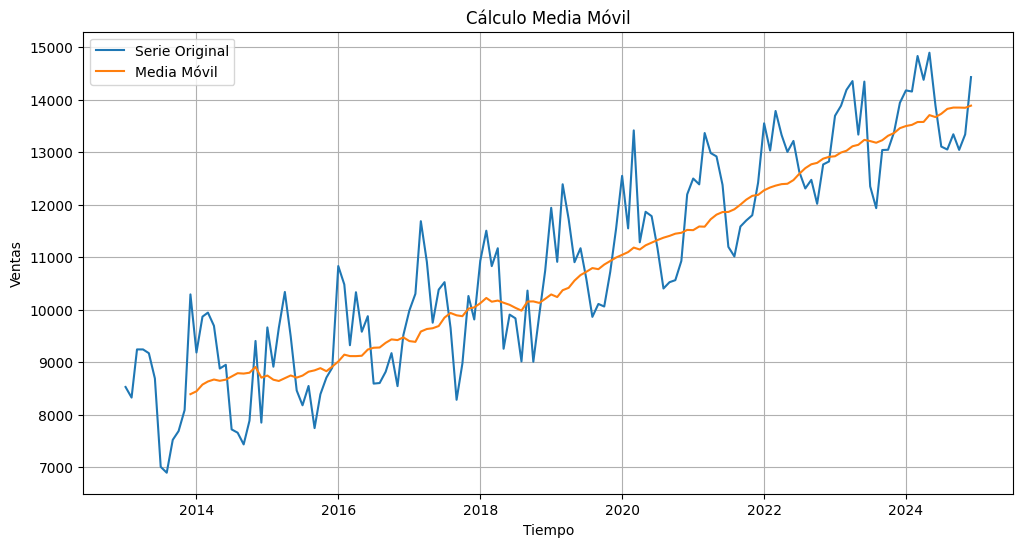

In [ ]:
# Media móvil

df['MediaMovil'] = df['Total_Ventas'].rolling(window=12).mean() # Ajuste de 30 días

# Gráfica comparativa
plt.figure(figsize=(12, 6))

plt.plot(df['Total_Ventas'], label='Serie Original')
plt.plot(df['MediaMovil'], label='Media Móvil')

plt.title('Cálculo Media Móvil')
plt.xlabel('Tiempo')
plt.ylabel('Ventas')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Modelo Aditivo

serie = df['Total_Ventas']

period = 12

decomp_add = seasonal_decompose(serie, model='additive', period=period)

rss_add = np.nansum(decomp_add.resid**2)

print(f"RSS aditivo:  {rss_add:.2f}")

RSS aditivo:  26632174.40


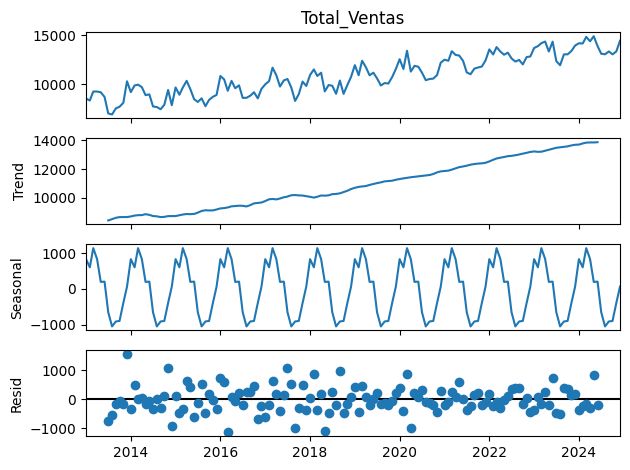

In [ ]:
decomp_add.plot()
plt.show()

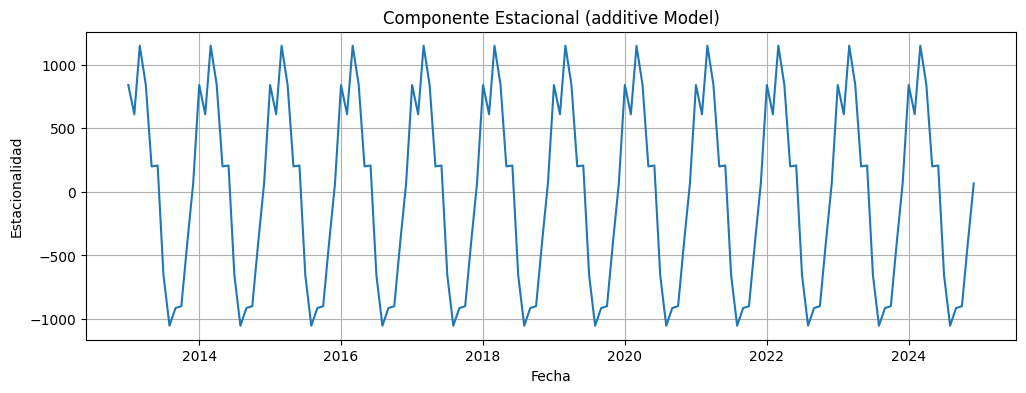

In [ ]:
# Descomposición con el modelo sugerido
decomposition_final = seasonal_decompose(df['Total_Ventas'], model='additive', period=12)

# Graficar solo el componente estacional
plt.figure(figsize=(12, 4))
plt.plot(decomposition_final.seasonal)
plt.title(f'Componente Estacional (additive Model)')
plt.ylabel('Estacionalidad')
plt.xlabel('Fecha')
plt.grid(True)
plt.show()

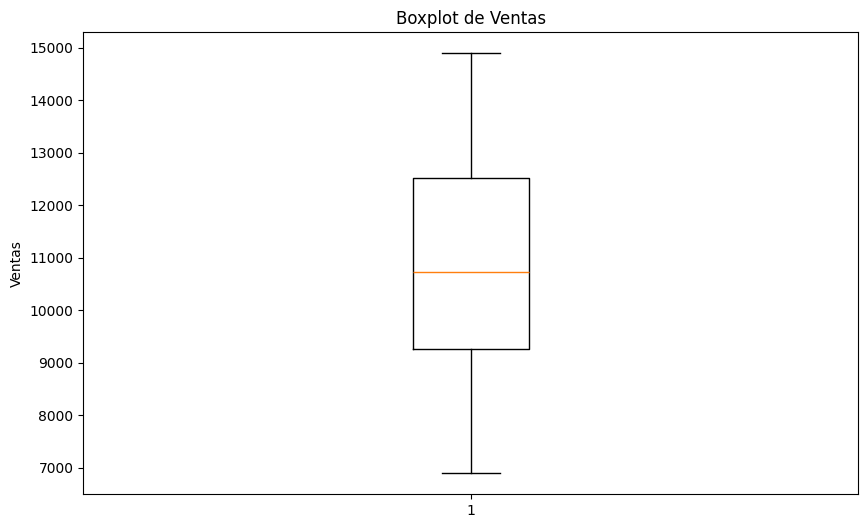

In [ ]:
plt.figure(figsize=(10, 6))
plt.boxplot(df['Total_Ventas'])
plt.title('Boxplot de Ventas')
plt.ylabel('Ventas')
plt.show()

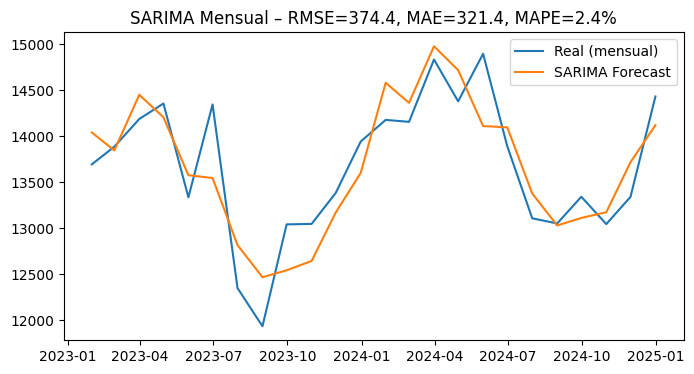

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Función de métricas
def compute_metrics(actual, forecast):
    rmse = np.sqrt(mean_squared_error(actual, forecast))
    mae  = mean_absolute_error(actual, forecast)
    mape = np.mean(np.abs((actual - forecast) / actual)) * 100
    return rmse, mae, mape

# 1) Carga y resampling a mensual
df = pd.read_csv('/content/dataset_ventas_pyme_2013_2024.csv', parse_dates=['Fecha'])
df.set_index('Fecha', inplace=True)

# Agregamos totales mensuales
monthly = df['Total_Ventas'].resample('ME').sum()

# 2) División train/test (último año fuera)
train_m = monthly[:'2022-12-31']
test_m  = monthly['2023-01-01':]

# 3) Ajuste SARIMA(p,d,q)x(P,D,Q,12)
#    - Reduce drásticamente la cantidad de puntos (≈132 vs 4018)
model_m = ARIMA(
    train_m,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    trend='n'      # sin drift, por simplicidad
).fit()

# 4) Pronóstico mensual
pred_m = model_m.forecast(steps=len(test_m))

# 5) Métricas y gráfico
rmse_m, mae_m, mape_m = compute_metrics(test_m, pred_m)

plt.figure(figsize=(8,4))
plt.plot(test_m.index, test_m,    label='Real (mensual)')
plt.plot(test_m.index, pred_m,    label='SARIMA Forecast')
plt.title(f'SARIMA Mensual – RMSE={rmse_m:.1f}, MAE={mae_m:.1f}, MAPE={mape_m:.1f}%')
plt.legend(); plt.show()

In [ ]:
forecast_6m = model_m.forecast(steps=30)
prediccion = forecast_6m.tail(6)

prediccion

,predicted_mean
2025-01-31,15114.907672
2025-02-28,14898.338916
2025-03-31,15512.405863
2025-04-30,15254.310448
2025-05-31,14645.223187
2025-06-30,14629.954375


In [ ]:
# prompt: me puedes ayudar a graficar este df prediccion como una gráfica de serie temporal

fig = go.Figure()

fig.add_trace(go.Scatter(x=prediccion.index, y=prediccion.values,
                         mode='lines',
                         name='Predicción SARIMA (6 meses)',
                         line=dict(color='green', width=2)))

fig.update_layout(
    title={
        'text': 'Predicción de Ventas SARIMA (Próximos 6 Meses)',
        'y':0.9,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top'
    },
    xaxis_title='Fecha',
    yaxis_title='Ventas Predichas',
    hovermode='x unified',
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    ),
    template= 'seaborn'
)

fig.show()

In [ ]:
#Gráfico de línea

fig = go.Figure()

fig.add_trace(go.Scatter(x=df.index, y=df['Total_Ventas'],
                         mode='lines',
                         name='Ventas',
                         line=dict(color='green', width=2)))

fig.update_layout(
    title={
        'text': 'Ventas totales a lo largo del Tiempo',
        'y':0.9,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top'
    },
    xaxis_title='Fecha',
    yaxis_title='Ventas',
    hovermode='x unified',
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    ),
    template= 'seaborn'
)

fig.show()

In [ ]:
import pickle

# Guardar el modelo en un archivo
with open('modelo_sarima.pkl', 'wb') as f:
    pickle.dump(model_m, f)